gamma: 0.1670, sigma: 0.0434


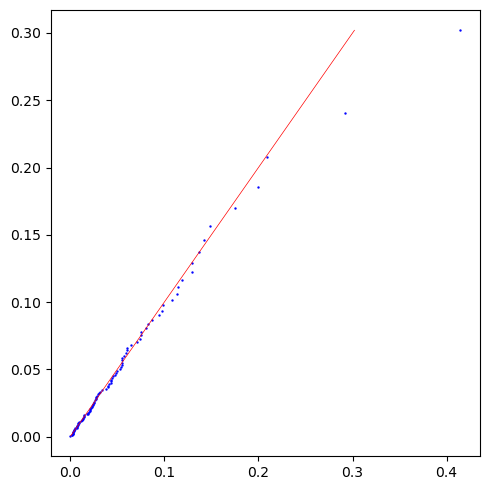

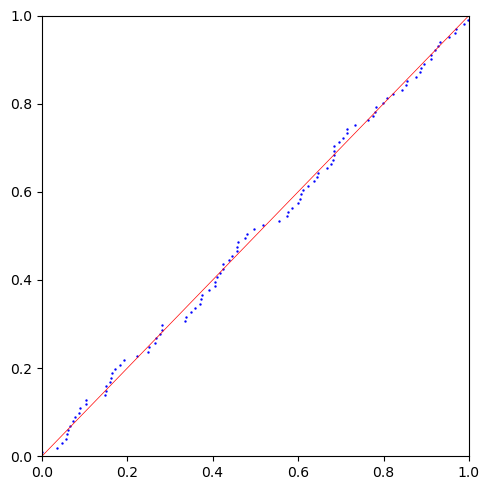

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto

# ── 1. Load data ─────────────────────────────────────────────────
r_bayer = pd.read_csv("../Data/BAYN_DE_log_returns.csv",
                      parse_dates=["Date"]).set_index("Date")["Close"]

r_bmw = pd.read_csv("../Data/BMW_DE_log_returns.csv",
                    parse_dates=["Date"]).set_index("Date")["Close"]
r_bmw.index = pd.to_datetime(r_bmw.index, format="%d.%m.%Y")

r_sie = pd.read_csv("../Data/SIE_DE_log_returns.csv",
                    parse_dates=["Date"]).set_index("Date")["Close"]
r_sie.index = pd.to_datetime(r_sie.index, format="%d.%m.%Y")

returns = pd.concat([r_bayer, r_bmw, r_sie], axis=1)
returns.columns = ["Bayer", "BMW", "Siemens"]
returns = returns.dropna()

# ── 2. Portfolio (match R) ───────────────────────────────────────
X = (returns @ np.array([1, 1, 1])).values
losses = -X

# ── 3. POT (top-n extremes) ─────────────────────────────────────
n = 100
tail_values = np.sort(losses)[-n:]
threshold = tail_values[0]
gpdt = np.sort(tail_values - threshold)

# ── 4. Fit GPD ──────────────────────────────────────────────────
c_fit, loc_fit, scale_fit = genpareto.fit(gpdt, floc=0)

gamma = c_fit
print(f"gamma: {gamma:.4f}, sigma: {scale_fit:.4f}")

# ── 5. QQ data ──────────────────────────────────────────────────
t = (np.arange(1, n + 1)) / (n + 1)
y1 = genpareto.ppf(t, c=c_fit, loc=loc_fit, scale=scale_fit)

# ── 6. PP data ──────────────────────────────────────────────────
y2 = genpareto.cdf(gpdt, c=c_fit, loc=loc_fit, scale=scale_fit)

# ── 7. QQ plot (SAVE separately) ────────────────────────────────
plt.figure(figsize=(5, 5))

plt.scatter(gpdt, y1, color="blue", s=0.5)
plt.plot(y1, y1, color="red", linewidth=0.5)

plt.tight_layout()
plt.savefig("qq_plot_GPD.png", dpi=200, transparent=True, bbox_inches="tight")   # ✅ save QQ
plt.show()
plt.close()  # important: close figure

# ── 8. PP plot (SAVE separately) ────────────────────────────────
plt.figure(figsize=(5, 5))

plt.scatter(y2, t, color="blue", s=0.5)
plt.plot(y2, y2, color="red", linewidth=0.5)


plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("pp_plot_GPD.png", dpi=200, transparent=True, bbox_inches="tight")   # ✅ save PP
plt.show()
plt.close()


**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto

BASE_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

BAYER_CSV = os.path.join(BASE_DIR, "BAYN_DE_log_returns.csv")
BMW_CSV = os.path.join(BASE_DIR, "BMW_DE_log_returns.csv")
SIE_CSV = os.path.join(BASE_DIR, "SIE_DE_log_returns.csv")

N_TAIL = 100

**Cell 2 — Load and combine returns**

In [2]:
r_bayer = pd.read_csv(BAYER_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_bmw = pd.read_csv(BMW_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_sie = pd.read_csv(SIE_CSV, parse_dates=["Date"]).set_index("Date")["Close"]

returns = pd.concat([r_bayer, r_bmw, r_sie], axis=1)
returns.columns = ["Bayer", "BMW", "Siemens"]
returns = returns.dropna()

print(f"Sample date range: {returns.index.min().date()} to {returns.index.max().date()}")
print(f"Total observations: {len(returns)}")

Sample date range: 1996-12-17 to 2026-05-04
Total observations: 7522


**Cell 3 — Equal-weighted portfolio losses**

In [3]:
b = np.array([1, 1, 1]) / 3
X = (returns @ b).values
losses = -X

**Cell 4 — POT: select top-n extremes and threshold excess**

In [4]:
tail_values = np.sort(losses)[-N_TAIL:]
threshold = tail_values[0]
gpdt = np.sort(tail_values - threshold)

print(f"Threshold (100th largest loss): {threshold:.6f}")

Threshold (100th largest loss): 0.044564


**Cell 5 — Fit GPD to threshold excesses**

In [5]:
c_fit, loc_fit, scale_fit = genpareto.fit(gpdt, floc=0)
gamma = c_fit

print(f"Global GPD fit (POT method, n={N_TAIL} exceedances):")
print(f"  gamma (shape, xi) = {gamma:.4f}")
print(f"  sigma (scale)     = {scale_fit:.4f}")

Global GPD fit (POT method, n=100 exceedances):
  gamma (shape, xi) = 0.1670
  sigma (scale)     = 0.0145


**Cell 6 — Compute QQ-plot coordinates**

In [6]:
t = np.arange(1, N_TAIL + 1) / (N_TAIL + 1)
theoretical_q = genpareto.ppf(t, c=c_fit, loc=loc_fit, scale=scale_fit)
empirical_q = gpdt

**Cell 7 — Compute PP-plot coordinates**

In [7]:
theoretical_p = genpareto.cdf(gpdt, c=c_fit, loc=loc_fit, scale=scale_fit)
t_uniform = t

**Cell 8 — QQ-plot, display and save**

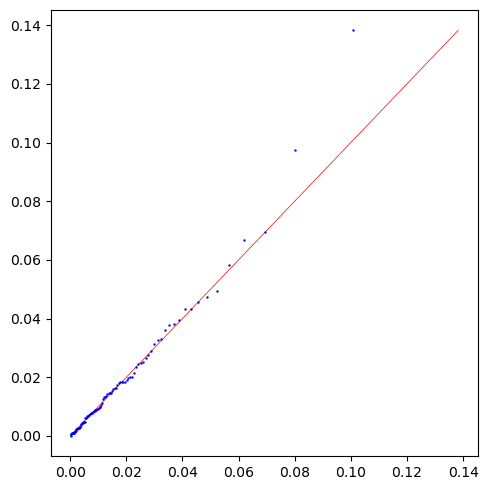

In [9]:
fig1, ax1 = plt.subplots(figsize=(5, 5))

ax1.scatter(theoretical_q, empirical_q, color="blue", s=0.5, zorder=3)
line_min, line_max = min(theoretical_q.min(), empirical_q.min()), max(theoretical_q.max(), empirical_q.max())
ax1.plot([line_min, line_max], [line_min, line_max], color="red", linewidth=0.5, zorder=2)

ax1.grid(False)
fig1.patch.set_alpha(0)
ax1.patch.set_alpha(0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "qq_plot_GPD.png"), dpi=200, transparent=True, bbox_inches="tight")
plt.show()

**Cell 9 — PP-plot, display and save**

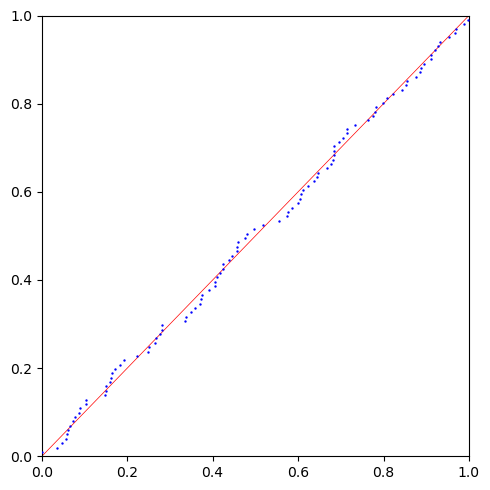

In [10]:
fig2, ax2 = plt.subplots(figsize=(5, 5))

ax2.scatter(theoretical_p, t_uniform, color="blue", s=0.5, zorder=3)
ax2.plot([0, 1], [0, 1], color="red", linewidth=0.5, zorder=2)

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid(False)
fig2.patch.set_alpha(0)
ax2.patch.set_alpha(0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pp_plot_GPD.png"), dpi=200, transparent=True, bbox_inches="tight")
plt.show()